# Notebook 11 - Clustering Algorithms
## Airbnb Capstone | Madrid and Tokyo market segmentation

**Goal:** start a dedicated clustering notebook, beginning with the same K-means setup used in the Show and Tell / tutor notebook.

This notebook is written for learning: each function is introduced close to where it is used, and each code cell is followed by a short explanation of what happened.

### Structure
1. Setup and paths
2. Feature selection for clustering
3. Load Madrid and Tokyo model-ready datasets
4. Prepare numeric clustering matrices
5. Scale features and explain distance
6. Elbow method and silhouette score
7. Fit K-means with 4 groups
8. Profile and name the groups
9. PCA visualisation
10. Save clustering outputs
11. Suggested next clustering algorithms

---
## 1. Setup and Paths

In [1]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="Set2")
pd.set_option("display.max_columns", 120)
pd.set_option("display.max_rows", 120)

RANDOM_STATE = 42

This cell imports only the libraries needed for clustering. K-means, PCA, silhouette score and scaling all come from scikit-learn. The `RANDOM_STATE` keeps the results reproducible.

In [2]:
def find_project_root(start: Path | None = None) -> Path:
    start = Path.cwd() if start is None else Path(start)
    for candidate in [start, *start.parents]:
        if (candidate / "1. Data").exists() and (candidate / "2. Code").exists():
            return candidate
    raise FileNotFoundError("Could not find the CAPSTONE project root.")


PROJECT_ROOT = find_project_root()
DATA_DIR = PROJECT_ROOT / "1. Data"
MODEL_READY_DIR = DATA_DIR / "model_ready"
ML_OUTPUT_DIR = DATA_DIR / "Outputs" / "ml_models"
CLUSTER_OUTPUT_DIR = ML_OUTPUT_DIR / "clustering"
CLUSTER_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("Project root:", PROJECT_ROOT)
print("Model-ready folder:", MODEL_READY_DIR)
print("Clustering output folder:", CLUSTER_OUTPUT_DIR)

Project root: C:\Users\georg\Desktop\Docs\Student Files\CAPSTONE
Model-ready folder: C:\Users\georg\Desktop\Docs\Student Files\CAPSTONE\1. Data\model_ready
Clustering output folder: C:\Users\georg\Desktop\Docs\Student Files\CAPSTONE\1. Data\Outputs\ml_models\clustering


This function searches upward from the current notebook location until it finds the project structure. That keeps the notebook runnable from inside `2. Code` without hard-coding a personal Windows path.

---
## 2. Feature Selection for K-means

In [3]:
CITY_FILES = {
    "Madrid": MODEL_READY_DIR / "madrid_model_ready.csv",
    "Tokyo": MODEL_READY_DIR / "tokyo_model_ready.csv",
}

CLUSTER_FEATURES = [
    "price_eur",
    "accommodates",
    "bedrooms",
    "amenities_count",
    "distance_to_center_km",
    "availability_365",
    "review_scores_rating",
    "host_is_superhost",
    "minimum_nights_capped",
]

FEATURE_REASONING = pd.DataFrame(
    [
        ["price_eur", "Market position", "Keeps the clusters commercially meaningful: cheaper vs premium listings."],
        ["accommodates", "Capacity", "Captures how many guests the listing can host."],
        ["bedrooms", "Capacity", "Adds a stronger space signal than guests alone."],
        ["amenities_count", "Quality / comfort", "Approximates how feature-rich the listing is."],
        ["distance_to_center_km", "Location", "Measures centrality, one of the clearest EDA drivers."],
        ["availability_365", "Supply / availability", "Separates often-booked or restricted listings from widely available ones."],
        ["review_scores_rating", "Guest quality signal", "Keeps guest satisfaction in the segmentation."],
        ["host_is_superhost", "Host quality", "Adds a simple host-trust signal."],
        ["minimum_nights_capped", "Booking rule", "Captures whether the listing behaves like short-stay or longer-stay supply."],
    ],
    columns=["attribute", "theme", "why used"],
)

N_CLUSTERS = 4
SEGMENT_LABELS = ["Value", "Standard", "Premium", "Luxury"]

print("K-means features used:")
display(FEATURE_REASONING)

K-means features used:


,attribute,theme,why used
0,price_eur,Market position,Keeps the clusters commercially meaningful: ch...
1,accommodates,Capacity,Captures how many guests the listing can host.
2,bedrooms,Capacity,Adds a stronger space signal than guests alone.
3,amenities_count,Quality / comfort,Approximates how feature-rich the listing is.
4,distance_to_center_km,Location,"Measures centrality, one of the clearest EDA d..."
5,availability_365,Supply / availability,Separates often-booked or restricted listings ...
6,review_scores_rating,Guest quality signal,Keeps guest satisfaction in the segmentation.
7,host_is_superhost,Host quality,Adds a simple host-trust signal.
8,minimum_nights_capped,Booking rule,Captures whether the listing behaves like shor...


We include `price_eur` because this is not a supervised prediction task; here price is part of the market-position profile we want the clusters to capture.

---
## 3. Load the Model-ready Datasets

In [4]:
def load_city_datasets(city_files: dict[str, Path]) -> dict[str, pd.DataFrame]:
    datasets = {}
    for city, path in city_files.items():
        if not path.exists():
            raise FileNotFoundError(f"Missing model-ready data for {city}: {path}")
        datasets[city] = pd.read_csv(path)
    return datasets


datasets = load_city_datasets(CITY_FILES)

for city, df in datasets.items():
    print(f"{city}: {df.shape[0]:,} rows, {df.shape[1]:,} columns")

Madrid: 17,770 rows, 87 columns
Tokyo: 23,765 rows, 86 columns


This function loads one model-ready file per city. We use the model-ready files because they already contain cleaned numeric features and engineered attributes prepared for modelling.

In [5]:
def check_feature_availability(datasets: dict[str, pd.DataFrame], features: list[str]) -> pd.DataFrame:
    rows = []
    for city, df in datasets.items():
        for feature in features:
            rows.append(
                {
                    "city": city,
                    "feature": feature,
                    "available": feature in df.columns,
                    "missing_values": int(df[feature].isna().sum()) if feature in df.columns else None,
                    "missing_pct": round(df[feature].isna().mean() * 100, 2) if feature in df.columns else None,
                }
            )
    return pd.DataFrame(rows)


feature_check = check_feature_availability(datasets, CLUSTER_FEATURES)
display(feature_check)

,city,feature,available,missing_values,missing_pct
0,Madrid,price_eur,True,0,0.00
1,Madrid,accommodates,True,0,0.00
2,Madrid,bedrooms,True,30,0.17
3,Madrid,amenities_count,True,0,0.00
4,Madrid,distance_to_center_km,True,0,0.00
5,Madrid,availability_365,True,0,0.00
6,Madrid,review_scores_rating,True,2825,15.90
7,Madrid,host_is_superhost,True,515,2.90
8,Madrid,minimum_nights_capped,True,0,0.00
9,Tokyo,price_eur,True,0,0.00


This check confirms that every selected clustering attribute exists in both city datasets and shows how much missing data would be removed before clustering.

---
## 4. Prepare Numeric Clustering Matrices

In [6]:
def prepare_clustering_frame(df: pd.DataFrame, features: list[str]) -> pd.DataFrame:
    available_features = [feature for feature in features if feature in df.columns]
    if len(available_features) < len(features):
        missing = sorted(set(features) - set(available_features))
        raise ValueError(f"Missing clustering features: {missing}")

    working = df[available_features].replace([np.inf, -np.inf], np.nan).copy()
    working = working.dropna().copy()
    working.insert(0, "model_ready_row", working.index)
    return working


working_frames = {}
for city, df in datasets.items():
    working_frames[city] = prepare_clustering_frame(df, CLUSTER_FEATURES)
    removed = len(df) - len(working_frames[city])
    print(f"{city}: {len(working_frames[city]):,} rows kept, {removed:,} rows removed because of missing clustering values")

Madrid: 14,446 rows kept, 3,324 rows removed because of missing clustering values
Tokyo: 19,158 rows kept, 4,607 rows removed because of missing clustering values


K-means cannot work with missing values, so this cell keeps only rows with all nine selected features available. The `model_ready_row` column preserves the original row position for traceability.

In [7]:
def describe_clustering_inputs(working_frames: dict[str, pd.DataFrame], features: list[str]) -> pd.DataFrame:
    summaries = []
    for city, frame in working_frames.items():
        summary = frame[features].describe().T.reset_index().rename(columns={"index": "feature"})
        summary.insert(0, "city", city)
        summaries.append(summary)
    return pd.concat(summaries, ignore_index=True)


input_summary = describe_clustering_inputs(working_frames, CLUSTER_FEATURES)
display(input_summary.round(2))

,city,feature,count,mean,std,min,25%,50%,75%,max
0,Madrid,price_eur,14446.0,115.68,61.35,8.00,70.00,106.00,150.00,305.00
1,Madrid,accommodates,14446.0,3.19,1.68,1.00,2.00,3.00,4.00,16.00
2,Madrid,bedrooms,14446.0,1.29,0.82,0.00,1.00,1.00,2.00,25.00
3,Madrid,amenities_count,14446.0,28.72,12.43,0.00,21.00,29.00,37.00,89.00
4,Madrid,distance_to_center_km,14446.0,2.71,2.48,0.01,0.78,1.85,4.04,13.49
5,Madrid,availability_365,14446.0,204.10,115.79,0.00,88.00,232.00,312.00,365.00
6,Madrid,review_scores_rating,14446.0,4.63,0.48,1.00,4.53,4.75,4.90,5.00
7,Madrid,host_is_superhost,14446.0,0.30,0.46,0.00,0.00,0.00,1.00,1.00
8,Madrid,minimum_nights_capped,14446.0,5.51,9.04,1.00,1.00,2.00,3.00,30.00
9,Tokyo,price_eur,19158.0,110.23,56.39,9.30,67.80,96.37,140.52,283.98


This summary shows the scale of each input before clustering. The features have very different units, so scaling is essential before using K-means.

---
## 5. Scale Features and Explain Distance

In [8]:
def scale_city_features(working: pd.DataFrame, features: list[str]) -> tuple[np.ndarray, StandardScaler]:
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(working[features])
    return X_scaled, scaler


scaled_data = {}
scalers = {}
for city, working in working_frames.items():
    X_scaled, scaler = scale_city_features(working, CLUSTER_FEATURES)
    scaled_data[city] = X_scaled
    scalers[city] = scaler
    print(f"{city}: scaled matrix shape = {X_scaled.shape}")

Madrid: scaled matrix shape = (14446, 9)
Tokyo: scaled matrix shape = (19158, 9)


K-means uses Euclidean distance. In scikit-learn, K-means minimizes the squared Euclidean distance between listings and their cluster centroid. Because Euclidean distance is sensitive to scale, we standardize every feature to mean 0 and standard deviation 1 before fitting the model.

---
## 6. Elbow Method and Silhouette Score

In [9]:
def calculate_kmeans_diagnostics(
    X_scaled: np.ndarray,
    city: str,
    k_values=range(2, 9),
    random_state: int = RANDOM_STATE,
) -> pd.DataFrame:
    rows = []
    for k in k_values:
        model = KMeans(n_clusters=k, random_state=random_state, n_init=20)
        labels = model.fit_predict(X_scaled)
        rows.append(
            {
                "city": city,
                "k": k,
                "inertia": model.inertia_,
                "silhouette_score": silhouette_score(
                    X_scaled,
                    labels,
                    sample_size=min(5000, len(X_scaled)),
                    random_state=random_state,
                ),
                "rows_used": len(X_scaled),
                "distance": "Euclidean on standardized features",
            }
        )
    return pd.DataFrame(rows)


diagnostic_frames = []
for city, X_scaled in scaled_data.items():
    diagnostic_frames.append(calculate_kmeans_diagnostics(X_scaled, city))

scores_df = pd.concat(diagnostic_frames, ignore_index=True)
display(scores_df.style.format({"inertia": "{:.2f}", "silhouette_score": "{:.4f}"}))

,city,k,inertia,silhouette_score,rows_used,distance
0,Madrid,2,109811.73,0.1825,14446,Euclidean on standardized features
1,Madrid,3,96673.56,0.1746,14446,Euclidean on standardized features
2,Madrid,4,86688.43,0.1903,14446,Euclidean on standardized features
3,Madrid,5,80359.23,0.1683,14446,Euclidean on standardized features
4,Madrid,6,73598.54,0.1740,14446,Euclidean on standardized features
5,Madrid,7,68917.96,0.1744,14446,Euclidean on standardized features
6,Madrid,8,65962.85,0.1616,14446,Euclidean on standardized features
7,Tokyo,2,142881.28,0.2222,19158,Euclidean on standardized features
8,Tokyo,3,125115.47,0.2566,19158,Euclidean on standardized features
9,Tokyo,4,109225.24,0.2141,19158,Euclidean on standardized features


This function tests several possible values of `k`. The elbow method uses inertia, while silhouette score checks how well separated the clusters are. Higher silhouette is better; lower inertia is expected as k increases, so we look for where improvement begins to flatten.

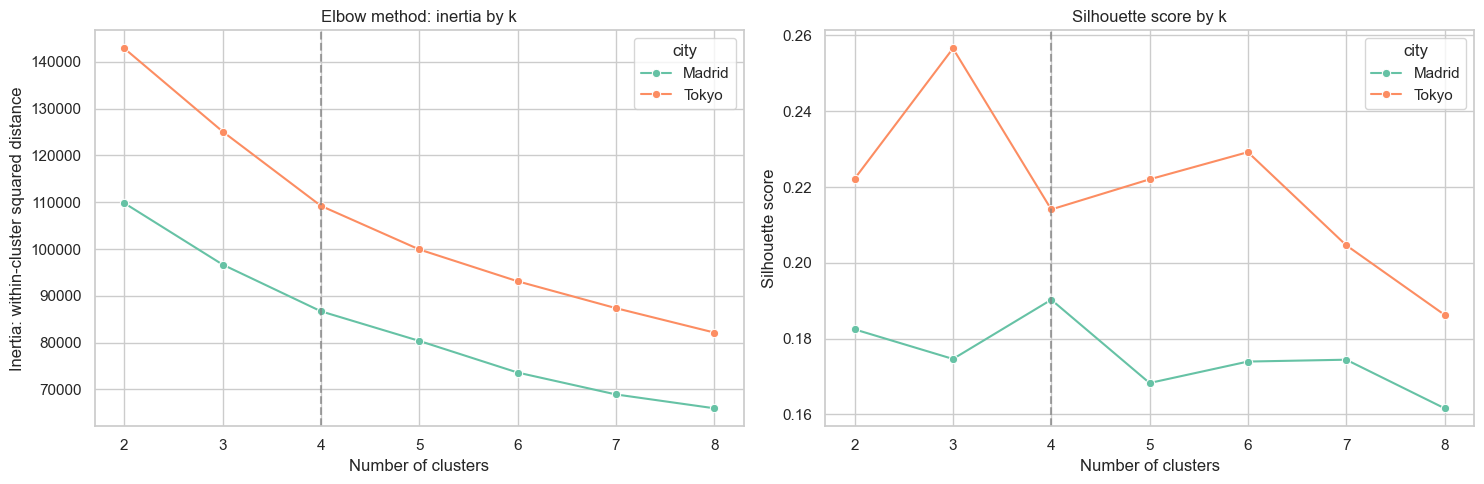

In [10]:
def plot_kmeans_diagnostics(scores: pd.DataFrame, selected_k: int = N_CLUSTERS) -> None:
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))

    sns.lineplot(data=scores, x="k", y="inertia", hue="city", marker="o", ax=axes[0])
    axes[0].axvline(selected_k, color="grey", linestyle="--", alpha=0.7)
    axes[0].set_title("Elbow method: inertia by k")
    axes[0].set_xlabel("Number of clusters")
    axes[0].set_ylabel("Inertia: within-cluster squared distance")

    sns.lineplot(data=scores, x="k", y="silhouette_score", hue="city", marker="o", ax=axes[1])
    axes[1].axvline(selected_k, color="grey", linestyle="--", alpha=0.7)
    axes[1].set_title("Silhouette score by k")
    axes[1].set_xlabel("Number of clusters")
    axes[1].set_ylabel("Silhouette score")

    plt.tight_layout()
    plt.show()


plot_kmeans_diagnostics(scores_df)

This plot is the main visual validation for choosing `k`. This version uses `k=4`, which keeps the groups easy to explain as Value, Standard, Premium and Luxury.

---
## 7. Fit K-means with Four Groups

In [11]:
def fit_kmeans_segments(
    working: pd.DataFrame,
    X_scaled: np.ndarray,
    features: list[str],
    n_clusters: int = N_CLUSTERS,
    random_state: int = RANDOM_STATE,
) -> tuple[pd.DataFrame, KMeans]:
    model = KMeans(n_clusters=n_clusters, random_state=random_state, n_init=30)
    segmented = working.copy()
    segmented["cluster_id"] = model.fit_predict(X_scaled)
    return segmented, model


segmented_frames = {}
kmeans_models = {}
for city in working_frames:
    segmented, model = fit_kmeans_segments(working_frames[city], scaled_data[city], CLUSTER_FEATURES)
    segmented_frames[city] = segmented
    kmeans_models[city] = model
    print(f"{city}: fitted K-means with {model.n_clusters} clusters")

Madrid: fitted K-means with 4 clusters
Tokyo: fitted K-means with 4 clusters


This cell fits the final K-means model separately for Madrid and Tokyo. The raw cluster numbers are arbitrary: cluster 0 is not automatically cheaper or better than cluster 1. We profile the clusters next before naming them.

---
## 8. Profile and Name the Groups

In [12]:
def profile_kmeans_segments(segmented: pd.DataFrame, city: str) -> tuple[pd.DataFrame, pd.DataFrame]:
    profile = (
        segmented
        .groupby("cluster_id")
        .agg(
            listings=("price_eur", "size"),
            median_price_eur=("price_eur", "median"),
            mean_price_eur=("price_eur", "mean"),
            median_accommodates=("accommodates", "median"),
            median_bedrooms=("bedrooms", "median"),
            median_amenities=("amenities_count", "median"),
            median_distance_to_center_km=("distance_to_center_km", "median"),
            median_availability_365=("availability_365", "median"),
            mean_review_score=("review_scores_rating", "mean"),
            superhost_rate=("host_is_superhost", "mean"),
            median_minimum_nights=("minimum_nights_capped", "median"),
        )
        .reset_index()
        .sort_values("median_price_eur")
        .reset_index(drop=True)
    )

    profile["segment"] = SEGMENT_LABELS[:len(profile)]
    profile["city"] = city

    cluster_to_segment = dict(zip(profile["cluster_id"], profile["segment"]))
    labelled = segmented.copy()
    labelled["segment"] = labelled["cluster_id"].map(cluster_to_segment)
    labelled["city"] = city

    ordered_columns = [
        "city", "segment", "cluster_id", "listings", "median_price_eur", "mean_price_eur",
        "median_accommodates", "median_bedrooms", "median_amenities",
        "median_distance_to_center_km", "median_availability_365",
        "mean_review_score", "superhost_rate", "median_minimum_nights",
    ]
    profile = profile[ordered_columns]
    numeric_cols = profile.select_dtypes(include="number").columns
    profile[numeric_cols] = profile[numeric_cols].round(2)

    return profile, labelled


profile_frames = []
labelled_frames = []
for city, segmented in segmented_frames.items():
    profile, labelled = profile_kmeans_segments(segmented, city)
    profile_frames.append(profile)
    labelled_frames.append(labelled[["city", "model_ready_row", "cluster_id", "segment", *CLUSTER_FEATURES]])

profiles_df = pd.concat(profile_frames, ignore_index=True)
segments_df = pd.concat(labelled_frames, ignore_index=True)

display(profiles_df.style.format({
    "median_price_eur": "{:.2f}",
    "mean_price_eur": "{:.2f}",
    "median_accommodates": "{:.1f}",
    "median_bedrooms": "{:.1f}",
    "median_amenities": "{:.1f}",
    "median_distance_to_center_km": "{:.2f}",
    "median_availability_365": "{:.0f}",
    "mean_review_score": "{:.2f}",
    "superhost_rate": "{:.2%}",
    "median_minimum_nights": "{:.0f}",
}))

,city,segment,cluster_id,listings,median_price_eur,mean_price_eur,median_accommodates,median_bedrooms,median_amenities,median_distance_to_center_km,median_availability_365,mean_review_score,superhost_rate,median_minimum_nights
0,Madrid,Value,2,1674,87.00,97.82,2.0,1.0,28.0,1.99,238,4.56,25.00%,30
1,Madrid,Standard,0,6749,93.00,95.60,2.0,1.0,26.0,2.05,246,4.53,0.00%,1
2,Madrid,Premium,3,3304,99.00,103.87,2.0,1.0,34.0,2.06,177,4.84,100.00%,2
3,Madrid,Luxury,1,2719,187.00,190.85,6.0,2.0,32.0,1.21,244,4.65,23.00%,1
4,Tokyo,Value,0,1351,67.77,79.83,3.0,1.0,30.0,6.53,161,4.67,26.00%,30
5,Tokyo,Standard,1,7859,83.68,91.20,3.0,1.0,30.0,6.53,147,4.61,0.00%,1
6,Tokyo,Premium,3,6703,97.33,104.45,3.0,1.0,33.0,6.68,161,4.84,100.00%,2
7,Tokyo,Luxury,2,3245,181.18,180.89,8.0,3.0,38.0,7.44,203,4.82,58.00%,2


The groups are named after sorting each city's clusters by median price. The lowest-price cluster becomes Value, then Standard, Premium and Luxury. These labels are descriptive, not true class labels.

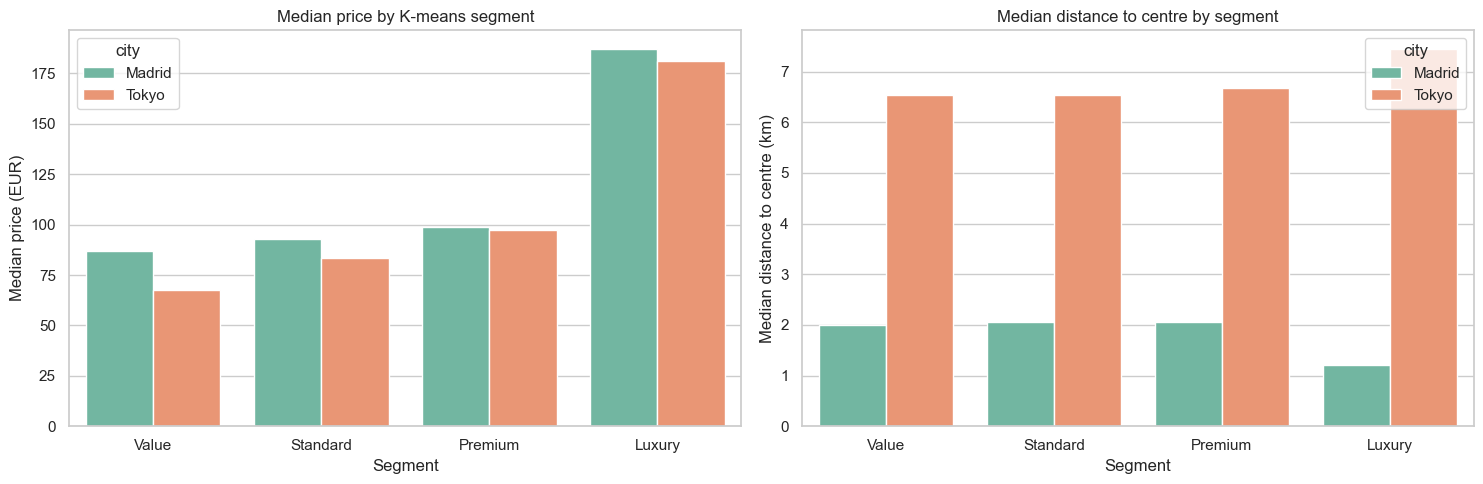

In [13]:
def plot_segment_profiles(profiles: pd.DataFrame) -> None:
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))

    sns.barplot(data=profiles, x="segment", y="median_price_eur", hue="city", ax=axes[0])
    axes[0].set_title("Median price by K-means segment")
    axes[0].set_xlabel("Segment")
    axes[0].set_ylabel("Median price (EUR)")

    sns.barplot(data=profiles, x="segment", y="median_distance_to_center_km", hue="city", ax=axes[1])
    axes[1].set_title("Median distance to centre by segment")
    axes[1].set_xlabel("Segment")
    axes[1].set_ylabel("Median distance to centre (km)")

    plt.tight_layout()
    plt.show()


plot_segment_profiles(profiles_df)

This plot checks whether the segment names make intuitive sense. The clearest pattern should be price, because we used median price to order the cluster labels.

---
## 9. PCA View of the Segments

In [14]:
def make_pca_sample(
    labelled: pd.DataFrame,
    X_scaled: np.ndarray,
    city: str,
    sample_size: int = 2500,
    random_state: int = RANDOM_STATE,
) -> pd.DataFrame:
    pca = PCA(n_components=2, random_state=random_state)
    coords = pca.fit_transform(X_scaled)
    coords_df = pd.DataFrame(coords, index=labelled.index, columns=["pc1", "pc2"])

    sample = labelled.sample(min(sample_size, len(labelled)), random_state=random_state).copy()
    sample = sample.join(coords_df.loc[sample.index])
    sample["city"] = city
    sample["pca_explained_variance_pc1"] = pca.explained_variance_ratio_[0]
    sample["pca_explained_variance_pc2"] = pca.explained_variance_ratio_[1]
    return sample[["city", "segment", "pc1", "pc2", "price_eur", "pca_explained_variance_pc1", "pca_explained_variance_pc2"]]


pca_samples = []
for city in segmented_frames:
    labelled = segments_df[segments_df["city"] == city].copy()
    labelled.index = working_frames[city].index
    pca_samples.append(make_pca_sample(labelled, scaled_data[city], city))

pca_sample_df = pd.concat(pca_samples, ignore_index=True)

explained = (
    pca_sample_df
    .groupby("city")[["pca_explained_variance_pc1", "pca_explained_variance_pc2"]]
    .first()
    .reset_index()
)
display(explained.round(3))

,city,pca_explained_variance_pc1,pca_explained_variance_pc2
0,Madrid,0.238,0.170
1,Tokyo,0.265,0.144


PCA compresses the nine scaled clustering features into two dimensions for plotting. This does not train the clusters; it only helps us visualise them.

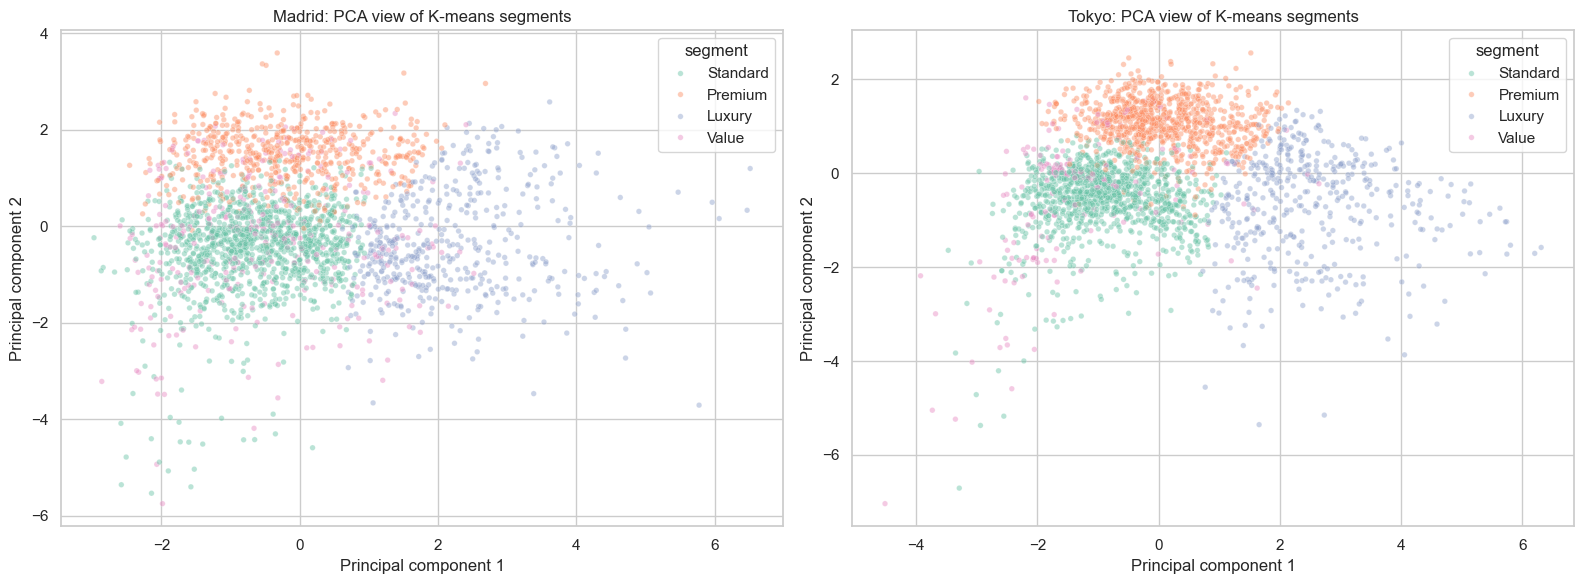

In [15]:
def plot_pca_segments(pca_sample: pd.DataFrame) -> None:
    cities = sorted(pca_sample["city"].unique())
    fig, axes = plt.subplots(1, len(cities), figsize=(8 * len(cities), 6))
    if len(cities) == 1:
        axes = [axes]

    for ax, city in zip(axes, cities):
        city_sample = pca_sample[pca_sample["city"] == city]
        sns.scatterplot(
            data=city_sample,
            x="pc1",
            y="pc2",
            hue="segment",
            s=16,
            alpha=0.45,
            ax=ax,
        )
        ax.set_title(f"{city}: PCA view of K-means segments")
        ax.set_xlabel("Principal component 1")
        ax.set_ylabel("Principal component 2")

    plt.tight_layout()
    plt.show()


plot_pca_segments(pca_sample_df)

The PCA scatterplot helps us see whether the K-means groups occupy different areas of the feature space. Some overlap is normal because Airbnb listings form a messy market rather than perfectly separate blocks.

---
## 10. Save Clustering Outputs

In [16]:
scores_out = CLUSTER_OUTPUT_DIR / "kmeans_scores.csv"
profiles_out = CLUSTER_OUTPUT_DIR / "kmeans_cluster_profiles.csv"
segments_out = CLUSTER_OUTPUT_DIR / "kmeans_listing_segments.csv"

scores_df.to_csv(scores_out, index=False)
profiles_df.to_csv(profiles_out, index=False)
segments_df.to_csv(segments_out, index=False)

print("Saved K-means scores to:", scores_out)
print("Saved cluster profiles to:", profiles_out)
print("Saved listing segment assignments to:", segments_out)

Saved K-means scores to: C:\Users\georg\Desktop\Docs\Student Files\CAPSTONE\1. Data\Outputs\ml_models\clustering\kmeans_scores.csv
Saved cluster profiles to: C:\Users\georg\Desktop\Docs\Student Files\CAPSTONE\1. Data\Outputs\ml_models\clustering\kmeans_cluster_profiles.csv
Saved listing segment assignments to: C:\Users\georg\Desktop\Docs\Student Files\CAPSTONE\1. Data\Outputs\ml_models\clustering\kmeans_listing_segments.csv


These files preserve the K-means diagnostics, the interpretable segment profiles, and the listing-level segment assignments. They can be reused later in reporting or in the chatbot.

---
## 11. Key Metrics and Interpretation

In [17]:
k4_summary = scores_df[scores_df["k"] == N_CLUSTERS].copy()
k4_summary = k4_summary[["city", "k", "inertia", "silhouette_score", "rows_used", "distance"]]
display(k4_summary.style.format({"inertia": "{:.2f}", "silhouette_score": "{:.4f}"}))

,city,k,inertia,silhouette_score,rows_used,distance
2,Madrid,4,86688.43,0.1903,14446,Euclidean on standardized features
9,Tokyo,4,109225.24,0.2141,19158,Euclidean on standardized features


For K-means, the key metrics are:

- **Inertia / elbow method:** lower is better, but it always decreases as k increases. We look for the point where the improvement starts to flatten.
- **Silhouette score:** ranges roughly from -1 to 1. Higher means listings are closer to their own cluster than to neighbouring clusters.
- **Distance used:** Euclidean distance on standardized features.
- **Chosen k:** 4, matching the tutor Show and Tell setup and giving interpretable Value, Standard, Premium and Luxury groups.